<a href="https://colab.research.google.com/github/ckurtz/teaching_UPC_UFRMI/blob/main/selfsupervised_demos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# References

[Course Webpage](https://sites.google.com/view/berkeley-cs294-158-sp20/home)

[1] Pathak, Deepak, et al. "Context encoders: Feature learning by inpainting." Proceedings of the IEEE conference on computer vision and pattern recognition. 2016.

[2] Gidaris, Spyros, Praveer Singh, and Nikos Komodakis. "Unsupervised representation learning by predicting image rotations." arXiv preprint arXiv:1803.07728 (2018).

[3] Chen, Ting, et al. "A simple framework for contrastive learning of visual representations." arXiv preprint arXiv:2002.05709 (2020).

[4] Noroozi, Mehdi, and Paolo Favaro. "Unsupervised learning of visual representations by solving jigsaw puzzles." European Conference on Computer Vision. Springer, Cham, 2016.

[5] Wang, Xiaolong, Allan Jabri, and Alexei A. Efros. "Learning correspondence from the cycle-consistency of time." Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition. 2019.

[6] Oord, Aaron van den, Yazhe Li, and Oriol Vinyals. "Representation learning with contrastive predictive coding." arXiv preprint arXiv:1807.03748 (2018).

[7] Hénaff, Olivier J., et al. "Data-efficient image recognition with contrastive predictive coding." arXiv preprint arXiv:1905.09272 (2019).

[8] Tian, Yonglong, Dilip Krishnan, and Phillip Isola. "Contrastive multiview coding." arXiv preprint arXiv:1906.05849 (2019).

[9] He, Kaiming, et al. "Momentum contrast for unsupervised visual representation learning." arXiv preprint arXiv:1911.05722 (2019).

[10] Doersch, Carl, Abhinav Gupta, and Alexei A. Efros. "Unsupervised visual representation learning by context prediction." Proceedings of the IEEE International Conference on Computer Vision. 2015.

[11] Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "U-net: Convolutional networks for biomedical image segmentation." International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

# Getting Started
Go to **Runtime -> Change runtime type** and make sure **Hardward accelerator** is set to **GPU**

In [1]:
!if [ -d cs294-158-ssl ]; then rm -Rf cs294-158-ssl; fi
!git clone https://github.com/ckurtz/cs294-158-ssl
!pip install cs294-158-ssl/

import os
os.chdir('cs294-158-ssl')

Cloning into 'cs294-158-ssl'...
remote: Enumerating objects: 615, done.
remote: Counting objects: 100% (98/98), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 615 (delta 92), reused 90 (delta 90), pack-reused 517 (from 1)
Receiving objects: 100% (615/615), 3.10 MiB | 3.52 MiB/s, done.
Resolving deltas: 100% (442/442), done.
Processing ./cs294-158-ssl
  Preparing metadata (setup.py) ... done
  Created wheel for deepul_helper: filename=deepul_helper-0.1.0-py3-none-any.whl size=25332 sha256=52f3ea1819689df5df3ec5fc6b585c8bf7b07f368d9e33929291dcd177f9eb23
  Stored in directory: /home/augustepl/.cache/pip/wheels/ef/70/ef/365963ed9b3d4f2e647d6bc800ca159a94002708e3b4ef8f8f
Successfully built deepul_helper
  Attempting uninstall: deepul_helper
    Found existing installation: deepul_helper 0.1.0
    Uninstalling deepul_helper-0.1.0:
      Successfully uninstalled deepul_helper-0.1.0


Run the cells below to download the necessary pretrained models. It should take a few minutes.

In [2]:
!wget https://camille-kurtz.com/teaching/data.zip
!unzip -qq data.zip
!rm data.zip

--2025-11-02 19:28:30--  https://camille-kurtz.com/teaching/data.zip
Resolving camille-kurtz.com (camille-kurtz.com)... 213.186.33.3
Connecting to camille-kurtz.com (camille-kurtz.com)|213.186.33.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4227668031 (3,9G) [application/zip]
Saving to: ‘data.zip’

data.zip            100%[===================>]   3,94G  4,67MB/s    in 14m 37s 

2025-11-02 19:43:07 (4,60 MB/s) - ‘data.zip’ saved [4227668031/4227668031]



In [3]:
!wget https://camille-kurtz.com/teaching/results.zip
!unzip -qq results.zip
!rm results.zip

--2025-11-02 19:43:34--  https://camille-kurtz.com/teaching/results.zip
Resolving camille-kurtz.com (camille-kurtz.com)... 213.186.33.3
Connecting to camille-kurtz.com (camille-kurtz.com)|213.186.33.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2636425194 (2,5G) [application/zip]
Saving to: ‘results.zip’

results.zip         100%[===================>]   2,46G  4,20MB/s    in 12m 2s  

2025-11-02 19:55:37 (3,48 MB/s) - ‘results.zip’ saved [2636425194/2636425194]



The models and demos shown were pre-trained. The code used for all the demos can be found in the github repo [here](https://github.com/wilson1yan/cs294-158-ssl). Follow the README to train models on CIFAR10 or ImageNet.

# Self-Supervised Learning Tasks
Self-supervised learning is a rapidly growing field, its success largely accelerated by growing compute and the vast amount of unlabeled data available for training. The hope is that by pretraining on specially designed self-supervised tasks, the models would be able to learn semantically meaningful representations to be used for downstream tasks. In the following demos, we will look at a few examples of these self-supervised tasks.

In [4]:
from deepul_helper.demos import load_model_and_data, evaluate_accuracy, display_nearest_neighbors, show_context_encoder_inpainting

%matplotlib inline

## Demo 1: Context Encoder [[1]](https://arxiv.org/abs/1604.07379)

The context encoder structures its self-supervised learning task by inpainting masked images. For example, the figure below shows different masking shapes, such as center masking, random block masking, and segmentation masking. Note that segmentation masking (c) is not purely self-supervised since we would need to train a image segmentation model which requires labels. However, the other two masking schemes (a) and (b) and purely self-supervised.

![](https://drive.google.com/uc?id=1fhzkULYTtyMGUUF2n9dlPayJSdcY5pRv)

More formally, the context encoder optimizes the following reconstruction loss:
$$\mathcal{L}_{rec} = \left\Vert \hat{M} \odot (x - F((1 - \hat{M})\odot x)) \right\Vert^2_2$$
where $\hat{M}$ is the masked region, $x$ is the image, and $F$ is the context encoder that tries to reconstruct the masked portion. In addition to the reconstruction loss, the paper introduces an adversarial loss that encourages more realistic inpaintings.
$$L_{adv} = \max_D \mathbb{E}_{x\in \chi} [\log(D(x)) + \log(1 - D(F((1-\hat{M})\odot x)))]$$
However, this demo does not use the adversarial portion of the loss.

### Example Code

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ContextEncoder(nn.Module):
    metrics = ['Loss']
    metrics_fmt = [':.4e']

    def __init__(self, dataset, n_classes):
        super().__init__()
        input_channels = 3

        self.latent_dim = 4000

        # Encodes the masked image
        self.encoder = nn.Sequential(
            # 128 x 128 Input
            nn.Conv2d(input_channels, 64, 4, stride=2, padding=1), # 64 x 64
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 64, 4, stride=2, padding=1), # 32 x 32
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), # 16 x 16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, stride=2, padding=1), # 8 x 8
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, stride=2, padding=1), # 4 x 4
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, self.latent_dim, 4) # 1 x 1
        )

        # Only reconstructs the masked part of the image and not the whole image
        self.decoder = nn.Sequential(
           nn.BatchNorm2d(self.latent_dim),
           nn.ReLU(inplace=True),
           nn.ConvTranspose2d(self.latent_dim, 512, 4, stride=1, padding=0), # 4 x 4
           nn.BatchNorm2d(512),
           nn.ReLU(inplace=True),
           nn.ConvTranspose2d(512, 256, 4, stride=2, padding=1), # 8 x 8
           nn.BatchNorm2d(256),
           nn.ReLU(inplace=True),
           nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1), # 16 x 16
           nn.BatchNorm2d(128),
           nn.ReLU(inplace=True),
           nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), # 32 x 32
           nn.BatchNorm2d(64),
           nn.ReLU(inplace=True),
           nn.ConvTranspose2d(64, input_channels, 4, stride=2, padding=1), # 64 x 64
           nn.Tanh()
        )

        self.dataset = dataset
        self.n_classes = n_classes

    def construct_classifier(self):
        classifier = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(self.latent_dim, affine=False),
            nn.Linear(self.latent_dim, self.n_classes)
        )
        return classifier

    def forward(self, images):
        # Extract a 64 x 64 center from 128 x 128 image
        images_center = images[:, :, 32:32+64, 32:32+64].clone()
        images_masked = images.clone()
        # Mask out a 64 x 64 center with slight overlap
        images_masked[:, 0, 32+4:32+64-4, 32+4:32+64-4] = 2 * 117.0/255.0 - 1.0
        images_masked[:, 1, 32+4:32+64-4, 32+4:32+64-4] = 2 * 104.0/255.0 - 1.0
        images_masked[:, 2, 32+4:32+64-4, 32+4:32+64-4] = 2 * 123.0/255.0 - 1.0

        z = self.encoder(images_masked)
        center_recon = self.decoder(z)

        return dict(Loss=F.mse_loss(center_recon, images_center)), torch.flatten(z, 1)

    def encode(self, images):
        images_masked = images
        images_masked[:, 0, 32+4:32+64-4, 32+4:32+64-4] = 2 * 117.0/255.0 - 1.0
        images_masked[:, 1, 32+4:32+64-4, 32+4:32+64-4] = 2 * 104.0/255.0 - 1.0
        images_masked[:, 2, 32+4:32+64-4, 32+4:32+64-4] = 2 * 123.0/255.0 - 1.0
        return self.encoder(images_masked)

    def reconstruct(self, images):
        images_center = images[:, :, 32:32+64, 32:32+64].clone()
        images_masked = images.clone()
        images_masked[:, 0, 32+4:32+64 - 4, 32+4:32+64-4] = 2 * 117.0/255.0 - 1.0
        images_masked[:, 1, 32+4:32+64 - 4, 32+4:32+64-4] = 2 * 104.0/255.0 - 1.0
        images_masked[:, 2, 32+4:32+64 - 4, 32+4:32+64-4] = 2 * 123.0/255.0 - 1.0

        z = self.encoder(images_masked)
        center_recon = self.decoder(z)

        images_recon = images_masked.clone()
        images_recon[:, :, 32:32+64, 32:32+64] = center_recon
        return images_masked, images_recon


### Inpainting Examples
For each pair of images, the left image is the masked input and the right the inpainted reconstruction.

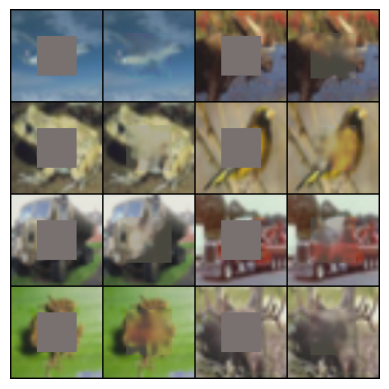

In [6]:
show_context_encoder_inpainting()

### Linear Classification
By design the model architecture is an encoder -> decoder module. We can use the bottleneck layer as our learned representation. Below, we show linear classification accuracy results on CIFAR10 using the learned representations.

In [7]:
model, linear_classifier, train_loader, test_loader = load_model_and_data('context_encoder')
evaluate_accuracy(model, linear_classifier, train_loader, test_loader)

Train Set
Top 1 Accuracy: 53.236, Top 5 Accuracy: 94.094

Test Set
Top 1 Accuracy: 45.77, Top 5 Accuracy: 90.29



### Nearest Neighbors
Another way to evaluate our learned representation is to look at nearest neighbors to random encoded images in latent space.

Image 1


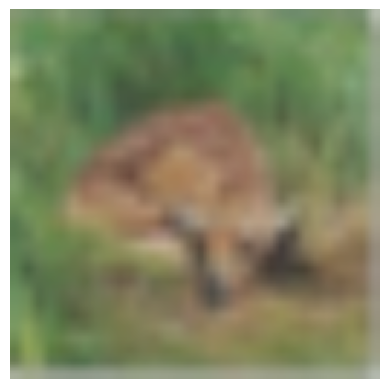

Top 16 Nearest Neighbors (in latent space)


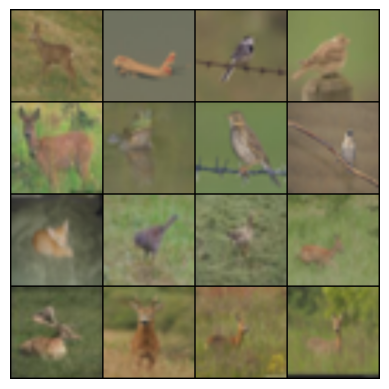

Image 2


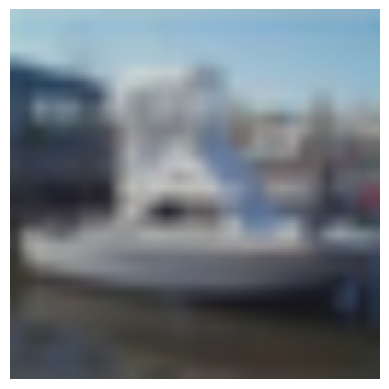

Top 16 Nearest Neighbors (in latent space)


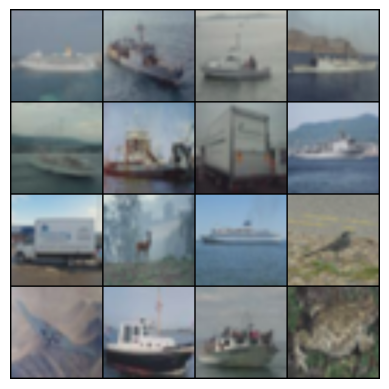

Image 3


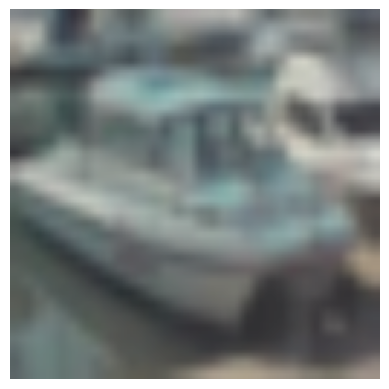

Top 16 Nearest Neighbors (in latent space)


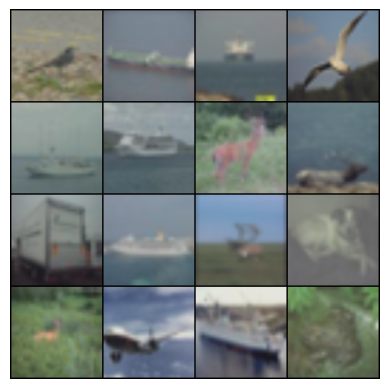

Image 4


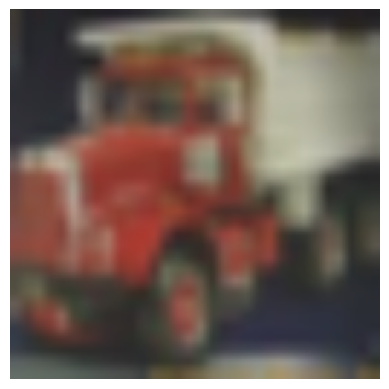

Top 16 Nearest Neighbors (in latent space)


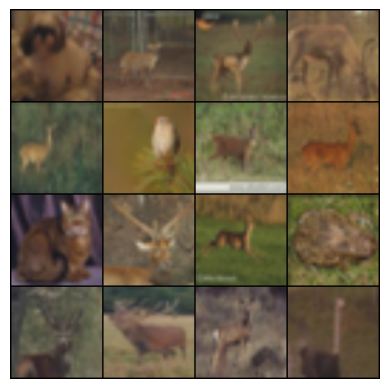

In [8]:
display_nearest_neighbors('context_encoder', model, test_loader)

## Demo 2: Rotation Prediction [[2]](https://arxiv.org/abs/1803.07728)

In this paper, the authors show that accurately predicting the degrees of rotation in images is a self-supervised learning task that learns good representations for downstream tasks.

![](https://drive.google.com/uc?id=1eHXLH-N_6uMGRzdf1Wjnga26qlS5-FRv)

More specifically, the authors showed that training a common CNN architecture (AlexNet, ResNet) on the rotation task learns semantically interpretable convolutional masks similar to those learned in supervised learning.

### Example Code

In [9]:
import math

import torch
import torch.nn as nn
import torch.nn.functional as F


class RotationPrediction(nn.Module):
    metrics = ['Loss', 'Acc1']
    metrics_fmt = [':.4e', ':6.2f']

    def __init__(self, dataset, n_classes):
        super().__init__()
        if dataset == 'cifar10':
            self.model = NetworkInNetwork()
            self.latent_dim = 192 * 8 * 8
            self.feat_layer = 'conv2'
        elif 'imagenet' in dataset:
            self.model = AlexNet()
            self.latent_dim = 256 * 13 * 13
            self.feat_layer = 'conv5'
        else:
            raise Exception('Unsupported dataset:', dataset)
        self.dataset = dataset
        self.n_classes = n_classes

    def construct_classifier(self):
        if self.dataset == 'cifar10':
            classifier = nn.Sequential(
                Flatten(),
                nn.BatchNorm1d(self.latent_dim, affine=False),
                nn.Linear(self.latent_dim, self.n_classes)
            )
        elif 'imagenet' in self.dataset:
            classifier = nn.Sequential(
                nn.AdaptiveMaxPool2d((6, 6)),
                nn.BatchNorm2d(256, affine=False),
                Flatten(),
                nn.Linear(256 * 6 * 6, self.n_classes)
            )
        else:
            raise Exception('Unsupported dataset:', dataset)
        return classifier

    def forward(self, images):
        batch_size = images.shape[0]
        images, targets = self._preprocess(images)
        targets = targets.to(images.get_device())

        logits, zs = self.model(images, out_feat_keys=('classifier', self.feat_layer))
        loss = F.cross_entropy(logits, targets)

        pred = logits.argmax(dim=-1)
        correct = pred.eq(targets).float().sum()
        acc = correct / targets.shape[0] * 100.

        return dict(Loss=loss, Acc1=acc), zs[:batch_size]

    def encode(self, images):
        zs = self.model(images, out_feat_keys=(self.feat_layer,))
        return zs

    def _preprocess(self, images):
        batch_size = images.shape[0]
        images_90 = torch.flip(images.transpose(2, 3), (2,))
        images_180 = torch.flip(images, (2, 3))
        images_270 = torch.flip(images, (2,)).transpose(2, 3)
        images_batch = torch.cat((images, images_90, images_180, images_270), dim=0)
        targets = torch.arange(4).long().repeat(batch_size)
        targets = targets.view(batch_size, 4).transpose(0, 1)
        targets = targets.contiguous().view(-1)
        return images_batch, targets

### Linear Classification
We can use the feature maps in the later convolutional layers of the pretrained model as our learned representation for linear classification.

In [10]:
model, linear_classifier, train_loader, test_loader = load_model_and_data('rotation')
evaluate_accuracy(model, linear_classifier, train_loader, test_loader)

Train Set
Top 1 Accuracy: 79.254, Top 5 Accuracy: 99.076

Test Set
Top 1 Accuracy: 79.91, Top 5 Accuracy: 99.12



### Nearest Neighbors
Another way to evaluate our learned representation is to look at nearest neighbors to random encoded images in latent space.

Image 1


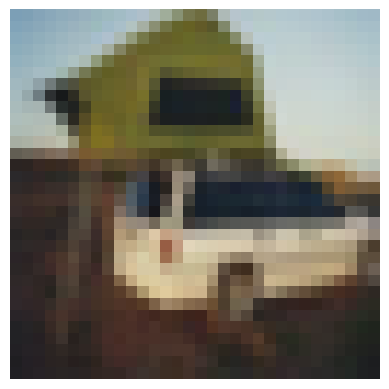

Top 16 Nearest Neighbors (in latent space)


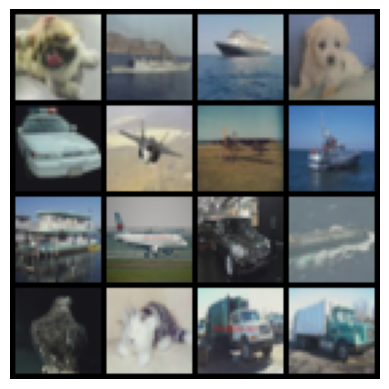

Image 2


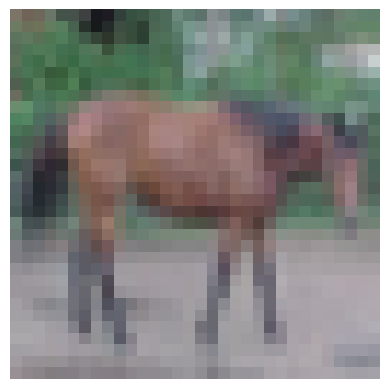

Top 16 Nearest Neighbors (in latent space)


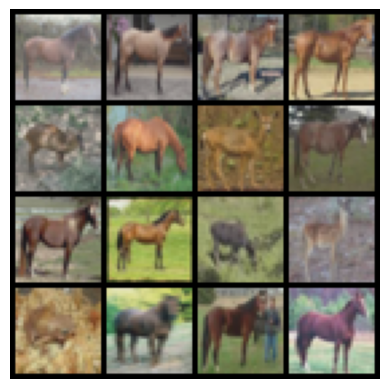

Image 3


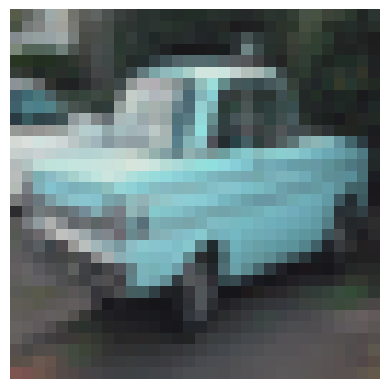

Top 16 Nearest Neighbors (in latent space)


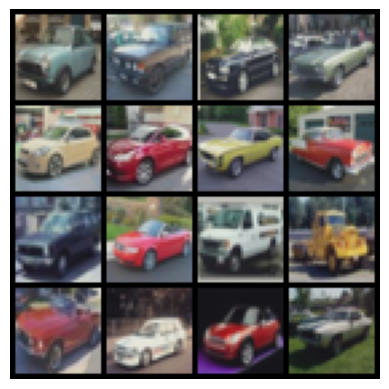

Image 4


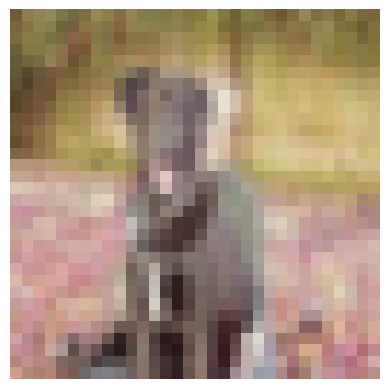

Top 16 Nearest Neighbors (in latent space)


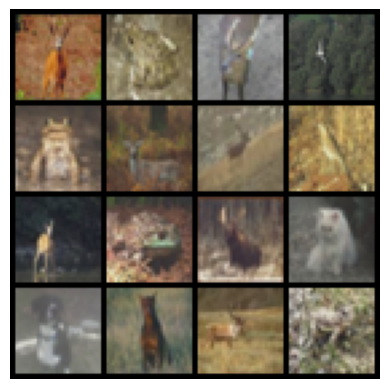

In [11]:
display_nearest_neighbors('rotation', model, test_loader)

## Demo 3: SimCLR [[3]](https://arxiv.org/abs/2002.05709)

SimCLR is a contrastive learning framework to learn strong visual representations. An image $x$ is processed using data augmentation to produce two variants $x_i$ and $x_j$ which are both fed into encoder $f$ (a CNN) and projection head $g$ (a small MLP). The models optimize a contrastive loss to maximally align projected latents $z_i, z_j$. We consider $x_i, x_j$ as a positive pair, and any other $x_i, x_k$ pairs (i.e. different images in the same batch) are negative pairs. A visual diagram of the training procedure is shown below (from the paper).

![](https://drive.google.com/uc?id=1XW1uIkUTMSa0DZncivSYXzM5gA5FIhF6)

More formally, the loss between positive example $z_i, z_j$ is:
$$\ell_{i,j} = -\log{\frac{\exp(\text{sim}(z_i, z_j)/\tau)}{\sum_{k=1}^{2N}\mathbb{1}_{[k\neq i]}\exp(\text{sim}(z_i, z_k)/\tau)}}$$
where $\text{sim}(z_i, z_j) = z_i^Tz_j / (\left\Vert z_i \right\Vert \left\Vert z_j \right\Vert)$. The loss function can also be interpreted as a standard cross entropy loss to classify positive samples where logits are constructed using a given similarity function.

Note: A common idea in contrastive learning methods is that a larger batch means more negative samples. Therefore, these methods usually benefit the most from large-batch learning compared to other self-supervised learning tasks.

### Example Code

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from deepul_helper.resnet import resnet_v1
from deepul_helper.batch_norm import SyncBatchNorm, BatchNorm1d

# Some code adapted from https://github.com/sthalles/SimCLR
class SimCLR(nn.Module):
    metrics = ['Loss']
    metrics_fmt = [':.4e']

    def __init__(self, dataset, n_classes, dist=None):
        super().__init__()
        self.temperature = 0.5
        self.projection_dim = 128

        if dataset == 'cifar10':
            resnet = resnet_v1((3, 32, 32), 50, 1, cifar_stem=True)
            resnet = SyncBatchNorm.convert_sync_batchnorm(resnet)
            self.resnet = resnet
            self.latent_dim = 2048
        elif 'imagenet' in dataset:
            resnet = resnet_v1((3, 128, 128), 50, 1, cifar_stem=False)
            if dist is not None:
                resnet = nn.SyncBatchNorm.convert_sync_batchnorm(resnet)
            self.resnet = resnet
            self.latent_dim = 2048

        self.proj = nn.Sequential(
            nn.Linear(self.latent_dim, self.projection_dim, bias=False),
            BatchNorm1d(self.projection_dim),
            nn.ReLU(inplace=True),
            nn.Linear(self.projection_dim, self.projection_dim, bias=False),
            BatchNorm1d(self.projection_dim, center=False)
        )

        self.dataset = dataset
        self.n_classes = n_classes
        self.dist = dist

    def construct_classifier(self):
        return nn.Sequential(nn.Linear(self.latent_dim, self.n_classes))

    def forward(self, images):
        n = images[0].shape[0]
        xi, xj = images
        hi, hj = self.encode(xi), self.encode(xj) # (N, latent_dim)
        zi, zj = self.proj(hi), self.proj(hj) # (N, projection_dim)
        zi, zj = F.normalize(zi), F.normalize(zj)

        # Each training example has 2N - 2 negative samples
        # 2N total samples, but exclude the current and positive sample

        if self.dist is None:
            zis = [zi]
            zjs = [zj]
        else:
            zis = [torch.zeros_like(zi) for _ in range(self.dist.get_world_size())]
            zjs = [torch.zeros_like(zj) for _ in range(self.dist.get_world_size())]

            self.dist.all_gather(zis, zi)
            self.dist.all_gather(zjs, zj)

        z1 = torch.cat((zi, zj), dim=0) # (2N, projection_dim)
        z2 = torch.cat(zis + zjs, dim=0) # (2N * n_gpus, projection_dim)

        sim_matrix = torch.mm(z1, z2.t()) # (2N, 2N * n_gpus)
        sim_matrix = sim_matrix / self.temperature
        # Mask out same-sample terms
        n_gpus = 1 if self.dist is None else self.dist.get_world_size()
        rank = 0 if self.dist is None else self.dist.get_rank()
        sim_matrix[torch.arange(n), torch.arange(rank*n, (rank+1)*n)]  = -float('inf')
        sim_matrix[torch.arange(n, 2*n), torch.arange((n_gpus+rank)*n, (n_gpus+rank+1)*n)] = -float('inf')

        targets = torch.cat((torch.arange((n_gpus+rank)*n, (n_gpus+rank+1)*n),
                             torch.arange(rank*n, (rank+1)*n)), dim=0)
        targets = targets.to(sim_matrix.get_device()).long()

        loss = F.cross_entropy(sim_matrix, targets, reduction='sum')
        loss = loss / n
        return dict(Loss=loss), hi

    def encode(self, images):
        return self.resnet(images[0])

    def get_features(self, images):
        return self.resnet.get_features(images)


### Linear Classification
We can use the encoded vector $h_i$ as our latent representation.

In [13]:
model, linear_classifier, train_loader, test_loader = load_model_and_data('simclr')
evaluate_accuracy(model, linear_classifier, train_loader, test_loader)

Train Set
Top 1 Accuracy: 90.16, Top 5 Accuracy: 99.492

Test Set
Top 1 Accuracy: 92.84, Top 5 Accuracy: 99.86



### Nearest Neighbors
Another way to evaluate our learned representation is to look at nearest neighbors to random encoded images in latent space.

Image 1


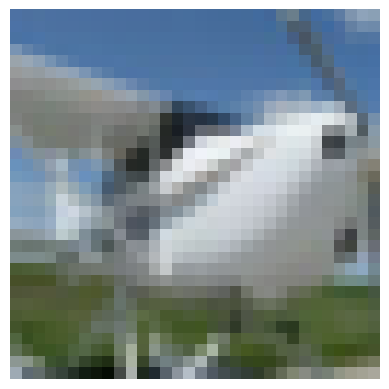

Top 16 Nearest Neighbors (in latent space)


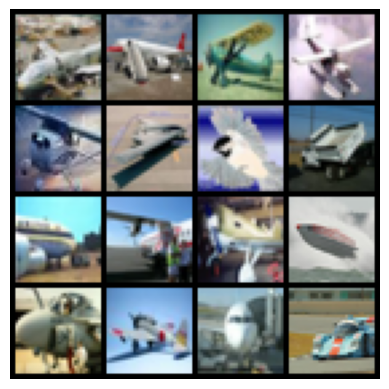

Image 2


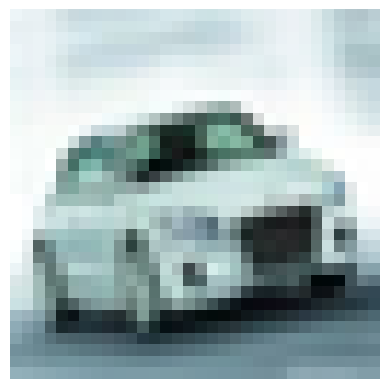

Top 16 Nearest Neighbors (in latent space)


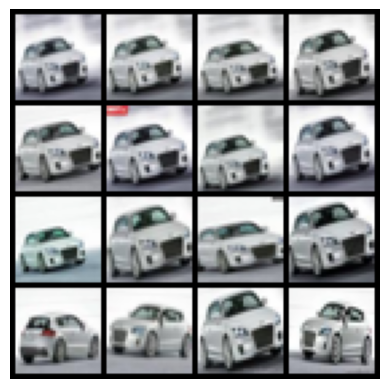

Image 3


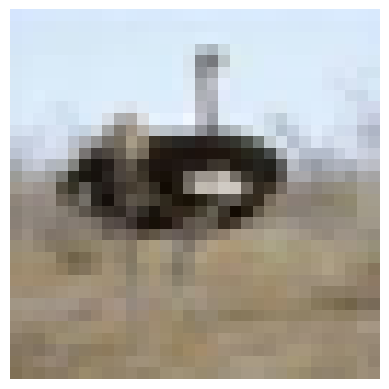

Top 16 Nearest Neighbors (in latent space)


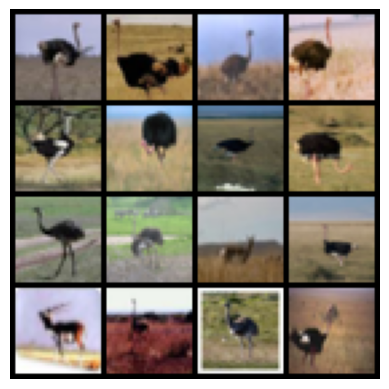

Image 4


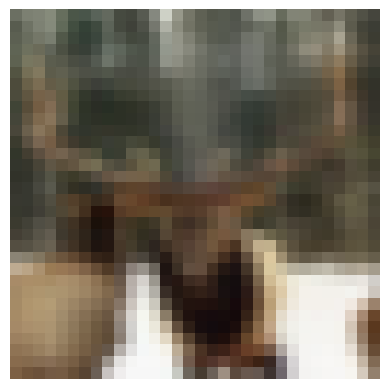

Top 16 Nearest Neighbors (in latent space)


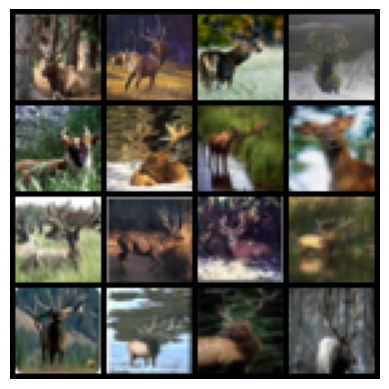

In [14]:
display_nearest_neighbors('simclr', model, test_loader)

## Other Tasks
In addition to the above tasks, prior work has also investigated other self-superivsed tasks such as solving jigsaw puzzles [[4]](https://arxiv.org/abs/1603.09246), cycle-consistency [[5]](https://arxiv.org/abs/1903.07593), contrastive learning [[6]](https://arxiv.org/abs/1807.03748)[[7]](https://arxiv.org/abs/1905.09272)[[8]](https://arxiv.org/abs/1906.05849)[[9]](https://arxiv.org/abs/1911.05722), and patch prediction [[10]](https://arxiv.org/abs/1505.05192). See [here](https://github.com/jason718/awesome-self-supervised-learning) for a great resource on more self-supervised learning papers.

# Demo 4: Using Representations for Downstream Tasks

After pretraining a model on a self-supervised learning task, we can use it for other downstream tasks. In this demo, we use the pre-trained ResNet50 backbone from training SimCLR on a subset of ImageNet to learn a semantic segmentation model on Pascal VOC 2012. We use a simple U-Net [[11]](https://arxiv.org/abs/1505.04597) architecture with skip connections across feature maps between the SimCLR encoder and learned upsampling decoder. We do not fine-tune the SimCLR ResNet50 backbone, and only optimize the upsampling portion.

![](https://drive.google.com/uc?id=19dxxcwof0IA0jyv0VCl4rnZZf3ajA22s)

The training script can be found in `train_segmentation.py` [here](https://github.com/wilson1yan/cs294-158-ssl/blob/master/train_segmentation.py).

## Example Code

In [15]:
# Code adapted from https://github.com/qubvel/segmentation_models.pytorch

import torch
import torch.nn as nn
import torch.nn.functional as F
from deepul_helper.resnet import NormReLU

class SegmentationModel(nn.Module):
    metrics = ['Loss']
    metrics_fmt = [':.4e']

    def __init__(self, n_classes):
        super().__init__()

        decoder_channels = (512, 256, 128, 64, 32)
        encoder_channels = (2048, 1024, 512, 256, 64) # Starting from head (resnet 50)

        # Construct decoder blocks
        in_channels = [encoder_channels[0]] + list(decoder_channels[:-1])
        skip_channels = list(encoder_channels[1:]) + [0]
        out_channels = decoder_channels
        blocks = [
            DecoderBlock(in_ch, skip_ch, out_ch)
            for in_ch, skip_ch, out_ch in zip(in_channels, skip_channels, out_channels)
        ]
        self.dec_blocks = nn.ModuleList(blocks)

        # Segmentation head for output prediction
        self.seg_head = nn.Conv2d(decoder_channels[-1], n_classes, kernel_size=3, padding=1)

    def forward(self, features, targets):
        features = features[1:] # remove first skip with same spatial resolution
        features = features[::-1] # reverse channels to start from head of encoder

        skips = features[1:]
        x = features[0]
        for i, decoder_block in enumerate(self.dec_blocks):
            skip = skips[i] if i < len(skips) else None
            x = decoder_block(x, skip)

        logits = self.seg_head(x)
        loss = F.cross_entropy(logits, targets)

        return dict(Loss=loss), logits


class DecoderBlock(nn.Module):
    def __init__(
            self,
            in_channels,
            skip_channels,
            out_channels,
    ):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels + skip_channels, out_channels,
                      kernel_size=3, padding=1),
            NormReLU((out_channels, None, None)), # only care about channel dim for BN
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            NormReLU((out_channels, None, None))
        )

    def forward(self, x, skip=None):
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        if skip is not None:
            x = torch.cat([x, skip], dim=1)
        x = self.conv1(x)
        x = self.conv2(x)
        return x

## Segmentation Results
Below, we show a random subset of segmentations from the trained model. Every set of 3 images consists of the original image, the labeled segmentation, and the predicted segmentation.

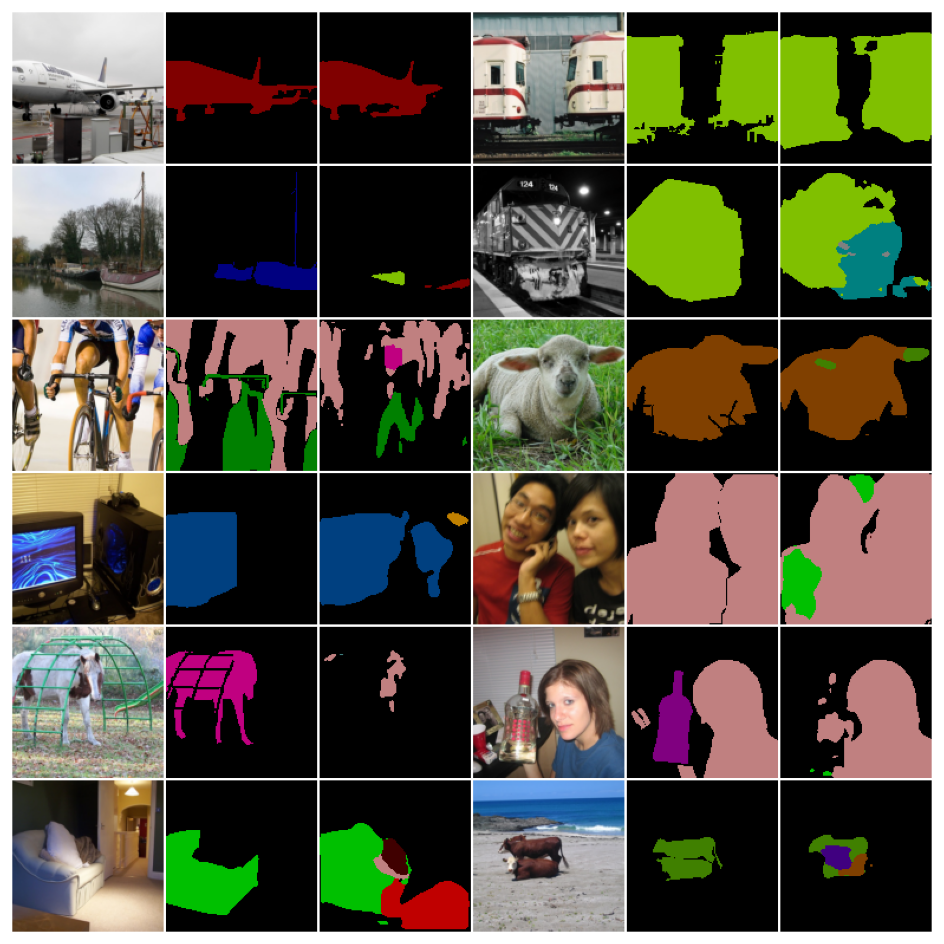

In [16]:
from deepul_helper.demos import show_segmentation
show_segmentation()

# Demo 5: Avoiding Trivial Representations in Self-Supervised Tasks

When designing a self-supervised learning task, it is important to make sure that no trivial solutions exists. In general, a learned solution is trivial if the model is able to successfully complete its task by taking advantage of low-level features. As a result, it doesn't learn a good representation so downstream performance is bad.

For example, in the jigsaw [[4]](https://arxiv.org/abs/1603.09246) task, a model can "cheat" by just looking at the boundary textures of the jigsaw pieces, or following and matching straight lines across different pieces. These issues can generally be fixed by ranndom cropping, shifting, and spacially jittering.

We look at two other less obvious aspects of images that may reduce performance.

## Chromatic Aberration

Chromatic aberration occurs when the different focal lengths of light results in the light not meeting all at the same point.
![from wikipedia](https://drive.google.com/uc?id=1PYGoQWnH0aAeiE_8t4ef5WDcq1UIQQ5t)

A example of very apparent chromatic aberration is shown below, where the green and magenta colors are clearly offset with each other:

![](https://drive.google.com/uc?id=1M1B6kV6ddBwyJse3FQT8_XBTeqs5s5WL)

Chromatic aberration generally becomes a problem in patch-based self-supervised learning tasks that design, such as solving jigsaw puzzles, or predicintg the correct location of a patch in an image In this case, the model can take advantage of the low-level chromatic aberration features to get a strong idea of where the patch is located without understanding the actual context.

Below is a quick demo of chromatic aberration in more realistic images, and possible fixes. Note that in general, chromatic aberration is fairly hard to spot with the naked eye, but deep learning models are still able to use it to their advantage.

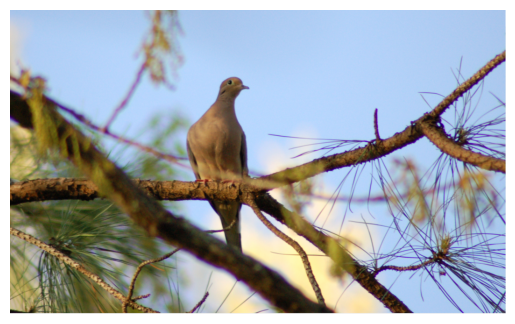

In [17]:
from PIL import Image
import matplotlib.pyplot as plt

# You can see some chromatic aberration in the purple fringes around the branches

image = Image.open('sample_images/chrom_ab_demo.png')
plt.figure()
plt.axis('off')
plt.imshow(image)
plt.show()

Chromatic aberration is generally fixed through conversion to grayscale, or color dropping. Color dropping works by dropping 2 of the color channels and replacing them with random noise uniform or Gaussian noise.

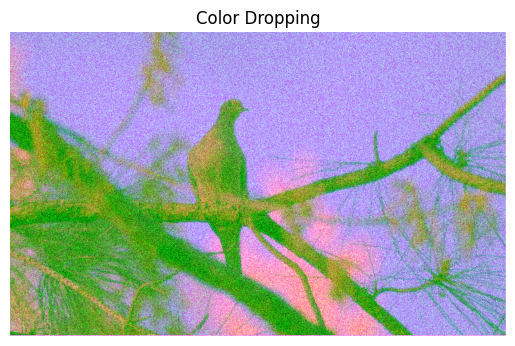

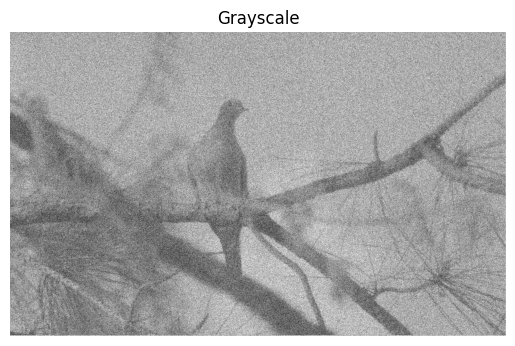

In [18]:
import numpy as np

# Color Dropping
# We will drop all channels except R
image_cpy = image.copy()
pixels = image_cpy.load()

arr = np.array(image_cpy)
std_R = np.std(arr[:, :, 0])
mean_G, mean_B = np.mean(arr[:, :, 1]), np.mean(arr[:, :, 2])

for i in range(image.size[0]):
  for j in range(image.size[1]):
    p = pixels[i, j] # (R, G, B, A)
    R, A = p[0], p[3]
    G = int(np.random.randn() * std_R + mean_G)
    B = int(np.random.randn() * std_R + mean_B)
    pixels[i, j] = (R, G, p[2], p[3])

plt.figure()
plt.title('Color Dropping')
plt.axis('off')
plt.imshow(image_cpy)
plt.show()

# Grayscale
image_cpy2 = image.copy()
pixels2 = image_cpy2.load()

for i in range(image.size[0]):
  for j in range(image.size[1]):
    p = pixels[i, j]
    G = int(0.3 * p[0] + 0.59 * p[1] + 0.11 * p[2])
    pixels2[i, j] = (G, G, G, 255)

plt.figure()
plt.title('Grayscale')
plt.axis('off')
plt.imshow(image_cpy2)
plt.show()

## Color Intensity Histograms

In the SimCLR paper, the authors show that the histogram of color intensities of different patches within the same image have very similar histograms, which may degrade training by encouraging models to look at low-level (pixel intensity) features to solve self-supervised tasks that involve matching positive patches of the same image.

Below, we run a similar demo to what was demonstrated in the paper

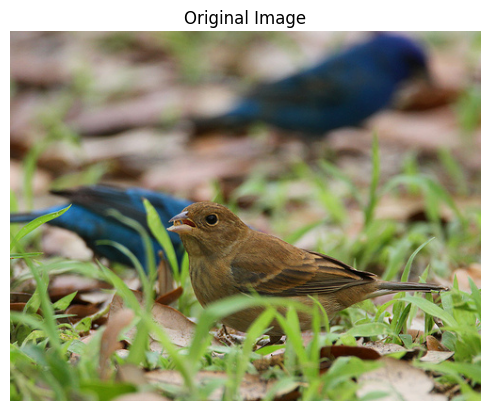

In [19]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open('sample_images/n01537544_19414.JPEG')
plt.figure()
plt.title('Original Image')
plt.axis('off')
plt.imshow(image)
plt.show()

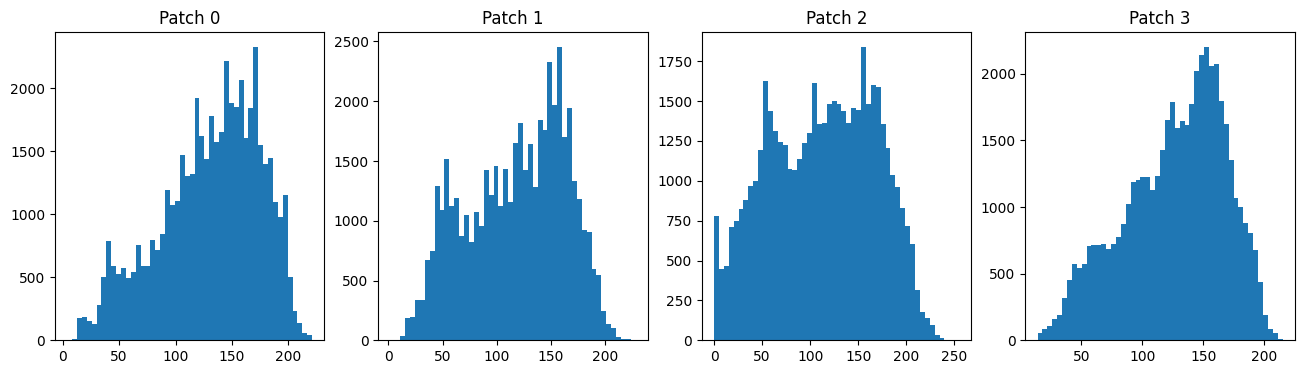

In [20]:
import numpy as np
arr = np.array(image)
H, W, _ = arr.shape

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
  r = np.random.randint(0, H - 128)
  c = np.random.randint(0, W - 128)
  patch = arr[r:r+128, c:c+128]

  axs[i].set_title(f'Patch {i}')
  axs[i].hist(patch.reshape(-1), bins=50)
plt.show()

Now we apply color jittering to mitigate this effect

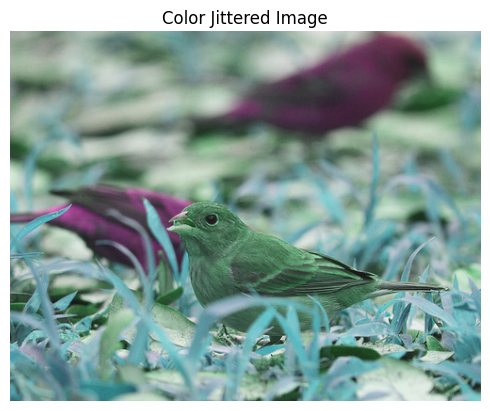

In [21]:
from torchvision import transforms

color_jitter = transforms.ColorJitter(0.3, 0.3, 0.3, 0.3)
jitter_img = color_jitter(image)

image = Image.open('sample_images/n01537544_19414.JPEG')
plt.figure()
plt.title('Color Jittered Image')
plt.axis('off')
plt.imshow(jitter_img)
plt.show()

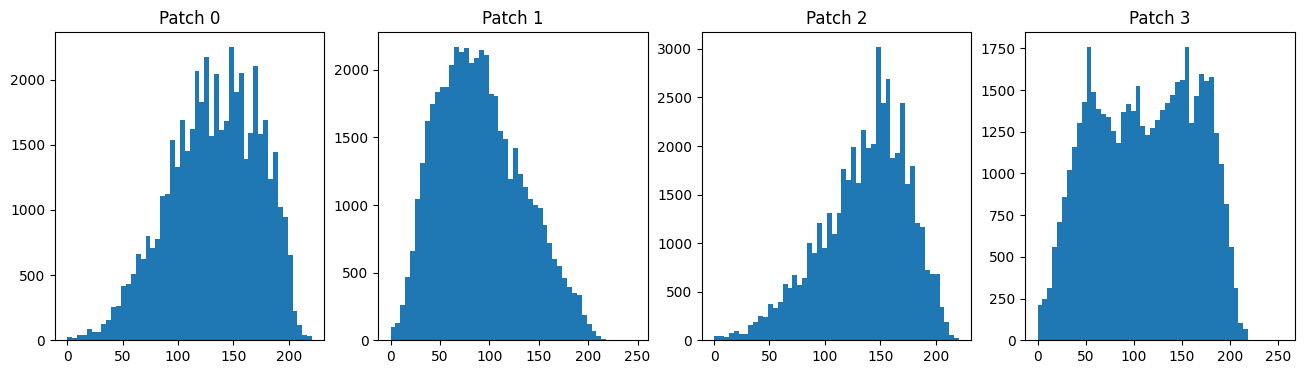

In [22]:
arr = np.array(image)
H, W, _ = arr.shape

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
  r = np.random.randint(0, H - 128)
  c = np.random.randint(0, W - 128)
  patch = arr[r:r+128, c:c+128]

  axs[i].set_title(f'Patch {i}')
  axs[i].hist(patch.reshape(-1), bins=50)
plt.show()

Evaluating Context Encoder...
Train Set
Top 1 Accuracy: 53.24, Top 5 Accuracy: 94.09

Test Set
Top 1 Accuracy: 45.77, Top 5 Accuracy: 90.29

Evaluating Rotation Prediction...
Train Set
Top 1 Accuracy: 79.57, Top 5 Accuracy: 99.19

Test Set
Top 1 Accuracy: 79.91, Top 5 Accuracy: 99.12

Evaluating SimCLR...
Train Set
Top 1 Accuracy: 90.18, Top 5 Accuracy: 99.48

Test Set
Top 1 Accuracy: 92.84, Top 5 Accuracy: 99.86


COMPARISON OF SELF-SUPERVISED LEARNING METHODS
              Model  Test Accuracy (%)
             SimCLR              92.84
Rotation Prediction              79.91
    Context Encoder              45.77


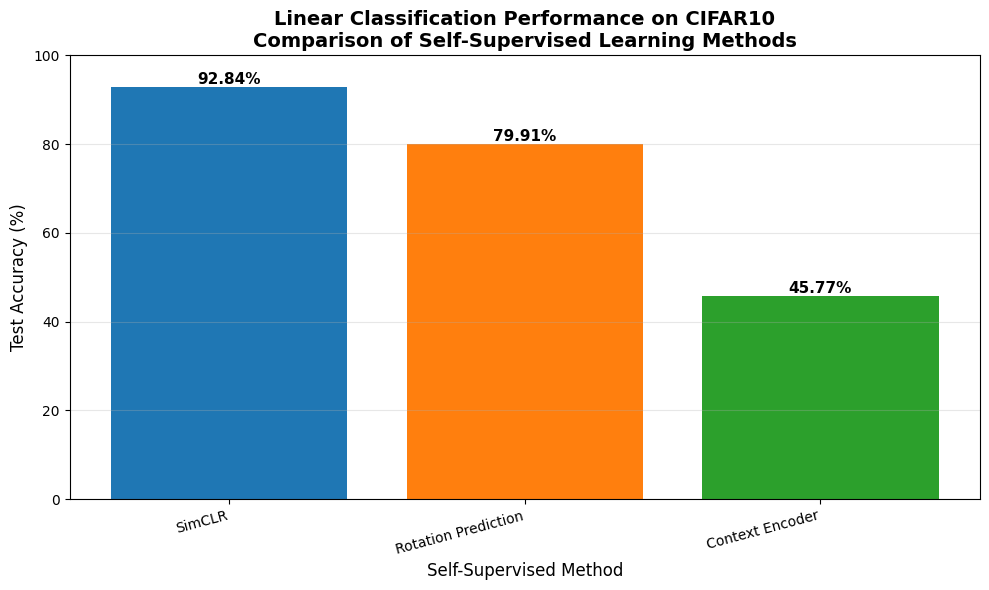


✓ Best performing method: SimCLR (92.84%)
✓ Worst performing method: Context Encoder (45.77%)
✓ Performance gap: 47.07%)


In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

def get_test_accuracy(model, linear_classifier, train_loader, test_loader):
    """Evaluate and return test Top-1 accuracy"""
    from deepul_helper.demos import evaluate_classifier
    
    train_acc1, train_acc5 = evaluate_classifier(model, linear_classifier, train_loader)
    test_acc1, test_acc5 = evaluate_classifier(model, linear_classifier, test_loader)
    
    print('Train Set')
    print(f'Top 1 Accuracy: {train_acc1:.2f}, Top 5 Accuracy: {train_acc5:.2f}\n')
    print('Test Set')
    print(f'Top 1 Accuracy: {test_acc1:.2f}, Top 5 Accuracy: {test_acc5:.2f}\n')
    
    return test_acc1  # Return Top-1 test accuracy


results = {}


print("="*60)
print("Evaluating Context Encoder...")
print("="*60)
model_ce, linear_classifier_ce, train_loader_ce, test_loader_ce = load_model_and_data('context_encoder')
acc_ce = get_test_accuracy(model_ce, linear_classifier_ce, train_loader_ce, test_loader_ce)
results['Context Encoder'] = acc_ce

# Evaluate Rotation Prediction
print("="*60)
print("Evaluating Rotation Prediction...")
print("="*60)
model_rot, linear_classifier_rot, train_loader_rot, test_loader_rot = load_model_and_data('rotation')
acc_rot = get_test_accuracy(model_rot, linear_classifier_rot, train_loader_rot, test_loader_rot)
results['Rotation Prediction'] = acc_rot

# Evaluate SimCLR
print("="*60)
print("Evaluating SimCLR...")
print("="*60)
model_simclr, linear_classifier_simclr, train_loader_simclr, test_loader_simclr = load_model_and_data('simclr')
acc_simclr = get_test_accuracy(model_simclr, linear_classifier_simclr, train_loader_simclr, test_loader_simclr)
results['SimCLR'] = acc_simclr


df_results = pd.DataFrame({
    'Model': list(results.keys()),
    'Test Accuracy (%)': list(results.values())
})

# Sort by accuracy
df_results = df_results.sort_values('Test Accuracy (%)', ascending=False)

# Display results table
print("\n" + "="*60)
print("COMPARISON OF SELF-SUPERVISED LEARNING METHODS")
print("="*60)
print(df_results.to_string(index=False))
print("="*60)

# Create bar plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10.colors
bars = ax.bar(df_results['Model'], df_results['Test Accuracy (%)'],
              color=[colors[i % len(colors)] for i in range(len(df_results))])

# Customize plot
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_xlabel('Self-Supervised Method', fontsize=12)
ax.set_title('Linear Classification Performance on CIFAR10\nComparison of Self-Supervised Learning Methods',
             fontsize=14, fontweight='bold')
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, df_results['Test Accuracy (%)'].values):
    ax.text(bar.get_x() + bar.get_width()/2., val,
            f'{val:.2f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# Additional statistics
print(f"\n✓ Best performing method: {df_results.iloc[0]['Model']} ({df_results.iloc[0]['Test Accuracy (%)']:.2f}%)")
print(f"✓ Worst performing method: {df_results.iloc[-1]['Model']} ({df_results.iloc[-1]['Test Accuracy (%)']:.2f}%)")
print(f"✓ Performance gap: {df_results.iloc[0]['Test Accuracy (%)'] - df_results.iloc[-1]['Test Accuracy (%)']:.2f}%)")


# Demo 6: Relative Position Prediction [[10]](https://arxiv.org/pdf/1505.05192.pdf)

Cette nouvelle tâche prétexte consiste à apprendre au modèle à prédire la position relative d'un patch par rapport à un patch de référence (query patch). C'est une des premières approches auto-supervisées proposées par Doersch et al.

## Principe

Le modèle reçoit deux patches d'une même image :
- Un **patch central** (query patch)
- Un **patch contextuel** venant d'une des 8 positions autour du centre

La tâche consiste à prédire quelle position (parmi 8) occupe le patch contextuel par rapport au patch central :

```
Position encoding (8 positions autour du centre):
    0 1 2
    3 X 4
    5 6 7
```

Cette tâche force le modèle à apprendre des représentations sémantiques pour comprendre la structure spatiale des objets.

Evaluating Relative Position Prediction...


100%|██████████| 170M/170M [00:37<00:00, 4.58MB/s] 


Using device: cuda

Training linear classifier for 5 epochs...
Epoch 1/5 | Batch 0/391 | Loss: 2.328 | Acc: 8.59%
Epoch 1/5 | Batch 100/391 | Loss: 1.342 | Acc: 43.46%
Epoch 1/5 | Batch 200/391 | Loss: 1.229 | Acc: 47.02%
Epoch 1/5 | Batch 300/391 | Loss: 1.518 | Acc: 49.38%
Epoch 1 completed | Train Accuracy: 50.46%

Epoch 2/5 | Batch 0/391 | Loss: 0.992 | Acc: 67.97%
Epoch 2/5 | Batch 100/391 | Loss: 1.303 | Acc: 58.90%
Epoch 2/5 | Batch 200/391 | Loss: 1.158 | Acc: 58.93%
Epoch 2/5 | Batch 300/391 | Loss: 1.117 | Acc: 58.91%
Epoch 2 completed | Train Accuracy: 58.95%

Epoch 3/5 | Batch 0/391 | Loss: 1.043 | Acc: 63.28%
Epoch 3/5 | Batch 100/391 | Loss: 1.264 | Acc: 62.62%
Epoch 3/5 | Batch 200/391 | Loss: 1.057 | Acc: 62.43%
Epoch 3/5 | Batch 300/391 | Loss: 1.195 | Acc: 62.13%
Epoch 3 completed | Train Accuracy: 62.03%

Epoch 4/5 | Batch 0/391 | Loss: 0.976 | Acc: 63.28%
Epoch 4/5 | Batch 100/391 | Loss: 0.847 | Acc: 65.22%
Epoch 4/5 | Batch 200/391 | Loss: 1.084 | Acc: 64.40%
Epoc

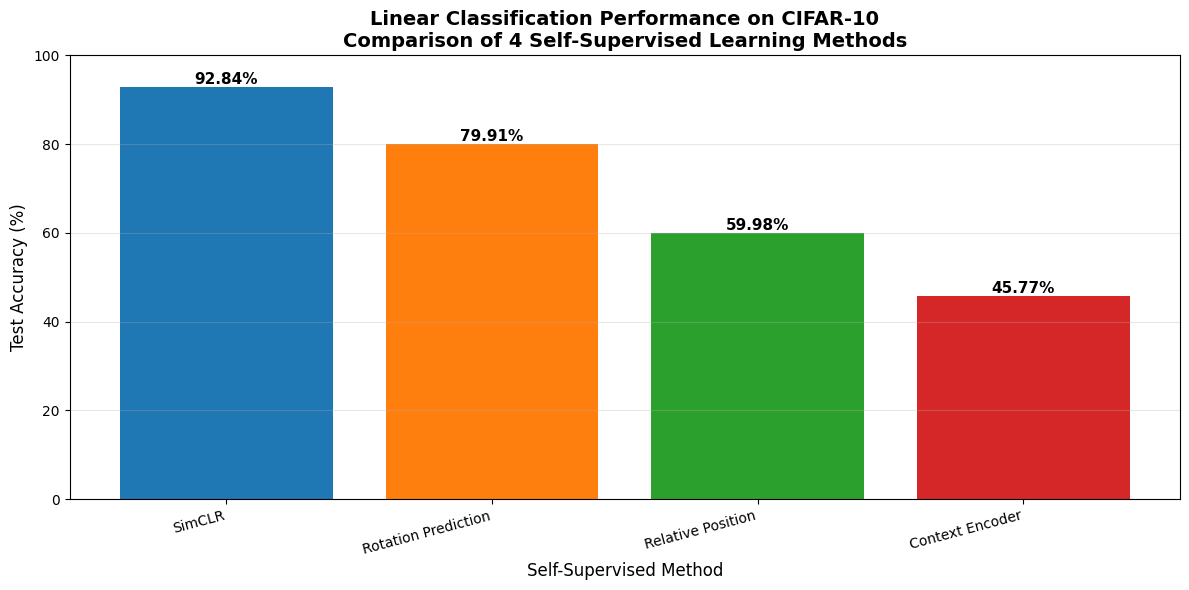


✓ Best: SimCLR (92.84%)
✓ Worst: Context Encoder (45.77%)


In [ ]:
# Évaluation Linear Classification - Relative Position Prediction
print("="*60)
print("Evaluating Relative Position Prediction...")
print("="*60)

import sys
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

# Import du modèle
parent_dir = os.path.dirname(os.getcwd())
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

if 'relative_position_prediction' in sys.modules:
    del sys.modules['relative_position_prediction']

from relative_position_prediction import RelativePositionPrediction

# Créer le modèle
model_rpp = RelativePositionPrediction(dataset='cifar10', n_classes=10)

# Charger CIFAR-10
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, 
                                              download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, 
                                             download=True, transform=transform)

train_loader_rpp = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader_rpp = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

# Construire le classifieur linéaire
linear_classifier_rpp = model_rpp.construct_classifier()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model_rpp = model_rpp.to(device)
linear_classifier_rpp = linear_classifier_rpp.to(device)

# Optimiseur pour le classifieur
optimizer = torch.optim.Adam(linear_classifier_rpp.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Entraînement rapide (5 epochs pour démo)
num_epochs = 5
print(f"\nTraining linear classifier for {num_epochs} epochs...")

for epoch in range(num_epochs):
    model_rpp.eval()  # Le modèle de features est figé
    linear_classifier_rpp.train()
    
    train_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (images, targets) in enumerate(train_loader_rpp):
        images, targets = images.to(device), targets.to(device)
        
        # Extraire les features (sans gradient)
        with torch.no_grad():
            features = model_rpp.encode(images)
            features = features.view(features.size(0), -1)
        
        # Forward pass du classifieur
        outputs = linear_classifier_rpp(features)
        loss = criterion(outputs, targets)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        
        if batch_idx % 100 == 0:
            print(f'Epoch {epoch+1}/{num_epochs} | Batch {batch_idx}/{len(train_loader_rpp)} | '
                  f'Loss: {loss.item():.3f} | Acc: {100.*correct/total:.2f}%')
    
    epoch_acc = 100. * correct / total
    print(f'Epoch {epoch+1} completed | Train Accuracy: {epoch_acc:.2f}%\n')

# Évaluation finale
print("="*60)
print("Final Evaluation on Test Set")
print("="*60)

model_rpp.eval()
linear_classifier_rpp.eval()

test_correct = 0
test_total = 0

with torch.no_grad():
    for images, targets in test_loader_rpp:
        images, targets = images.to(device), targets.to(device)
        
        # Extraire features
        features = model_rpp.encode(images)
        features = features.view(features.size(0), -1)
        
        # Prédiction
        outputs = linear_classifier_rpp(features)
        _, predicted = outputs.max(1)
        
        test_total += targets.size(0)
        test_correct += predicted.eq(targets).sum().item()

test_accuracy = 100. * test_correct / test_total

print(f'Test Accuracy: {test_accuracy:.2f}%')
print("="*60)

# Ajouter aux résultats pour comparaison
acc_rpp = test_accuracy
results['Relative Position'] = acc_rpp

# Mettre à jour le DataFrame
df_results = pd.DataFrame({
    'Model': list(results.keys()),
    'Test Accuracy (%)': list(results.values())
})

df_results = df_results.sort_values('Test Accuracy (%)', ascending=False)

# Afficher la comparaison complète
print("\n" + "="*60)
print("COMPARISON - ALL 4 SELF-SUPERVISED METHODS")
print("="*60)
print(df_results.to_string(index=False))
print("="*60)

# Graphique mis à jour
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab10.colors
bars = ax.bar(df_results['Model'], df_results['Test Accuracy (%)'],
              color=[colors[i % len(colors)] for i in range(len(df_results))])

ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_xlabel('Self-Supervised Method', fontsize=12)
ax.set_title('Linear Classification Performance on CIFAR-10\nComparison of 4 Self-Supervised Learning Methods',
             fontsize=14, fontweight='bold')
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, df_results['Test Accuracy (%)'].values):
    ax.text(bar.get_x() + bar.get_width()/2., val,
            f'{val:.2f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print(f"\n✓ Best: {df_results.iloc[0]['Model']} ({df_results.iloc[0]['Test Accuracy (%)']:.2f}%)")
print(f"✓ Worst: {df_results.iloc[-1]['Model']} ({df_results.iloc[-1]['Test Accuracy (%)']:.2f}%)")


CHARGEMENT DE CIFAR-100


100%|██████████| 169M/169M [00:39<00:00, 4.33MB/s] 


✓ CIFAR-100 loaded: 50000 train, 10000 test
✓ Number of classes: 100
✓ Image size: 32x32 (same as CIFAR-10)
✓ Using device: cuda

1/4: CONTEXT ENCODER - CIFAR-100
Epoch 1/5 | Train Acc: 17.88%
Epoch 2/5 | Train Acc: 26.15%
Epoch 3/5 | Train Acc: 30.74%
Epoch 4/5 | Train Acc: 33.78%
Epoch 5/5 | Train Acc: 36.39%

✓ Context Encoder CIFAR-100 Test Accuracy: 22.74%

2/4: ROTATION PREDICTION - CIFAR-100
Epoch 1/5 | Train Acc: 43.43%
Epoch 2/5 | Train Acc: 75.82%
Epoch 3/5 | Train Acc: 86.81%
Epoch 4/5 | Train Acc: 92.18%
Epoch 5/5 | Train Acc: 94.22%

✓ Rotation Prediction CIFAR-100 Test Accuracy: 49.90%

3/4: SIMCLR - CIFAR-100
Epoch 1/5 | Train Acc: 30.08%
Epoch 2/5 | Train Acc: 42.51%
Epoch 3/5 | Train Acc: 46.96%
Epoch 4/5 | Train Acc: 49.67%
Epoch 5/5 | Train Acc: 51.62%

✓ SimCLR CIFAR-100 Test Accuracy: 49.92%

4/4: RELATIVE POSITION - CIFAR-100
Epoch 1/5 | Train Acc: 20.73%
Epoch 2/5 | Train Acc: 32.26%
Epoch 3/5 | Train Acc: 38.54%
Epoch 4/5 | Train Acc: 43.29%
Epoch 5/5 | Train Ac

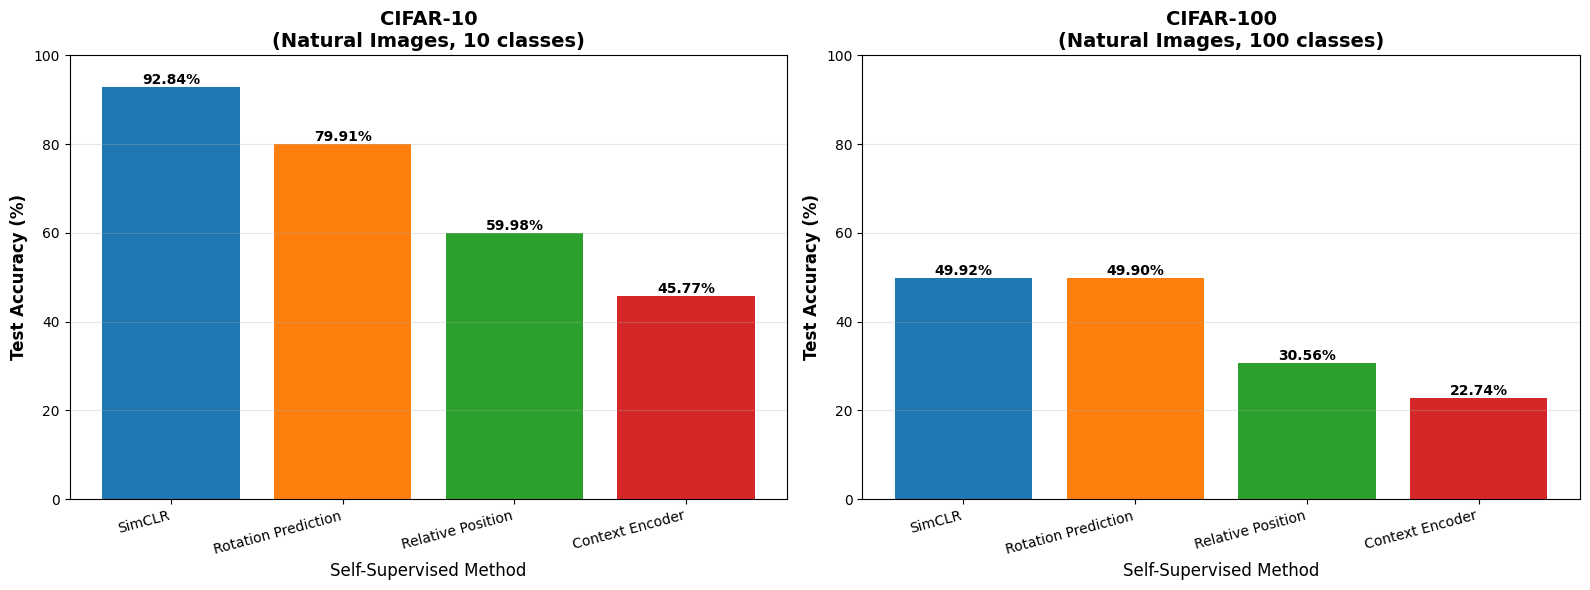

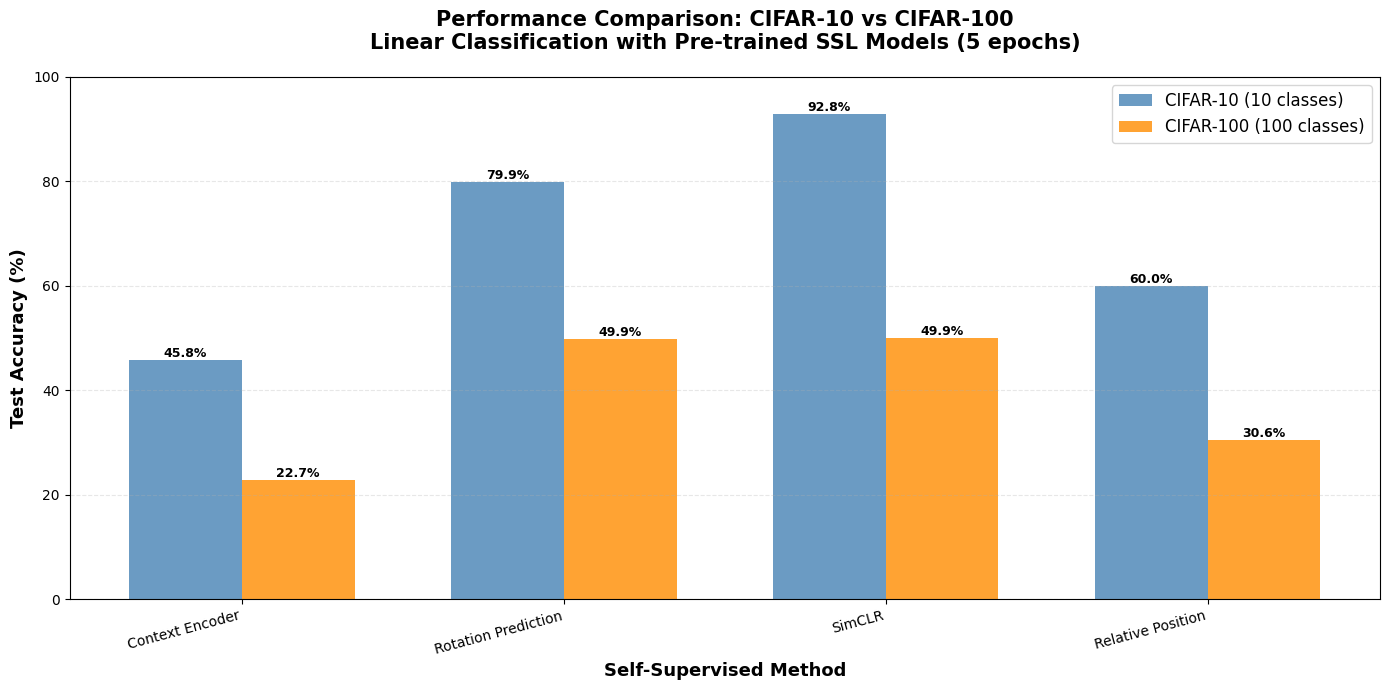


ANALYSE STATISTIQUE (CIFAR-10 vs CIFAR-100)

 CIFAR-10 Results:
   • Best: SimCLR (92.84%)
   • Worst: Context Encoder (45.77%)
   • Mean: 69.62%

CIFAR-100 Results:
   • Best: SimCLR (49.92%)
   • Worst: Context Encoder (22.74%)
   • Mean: 38.28%

 Performance Difference (CIFAR-10 → CIFAR-100):
   • Context Encoder          : Drop of 23.03%
   • Rotation Prediction      : Drop of 30.01%
   • SimCLR                   : Drop of 42.92%
   • Relative Position        : Drop of 29.42%

 OBSERVATIONS:
   • This test measures how well features learned on 10 classes generalize to 100 classes.
   • A smaller performance drop suggests more robust and generalizable features.
   • SimCLR and Rotation Prediction often show good generalization.

COMPARAISON COMPLÈTE - CIFAR-10 vs CIFAR-100


In [ ]:
# ============================================================
# ENTRAÎNEMENT ET ÉVALUATION SUR CIFAR-100
# 100 classes, images 32x32, 50k train, 10k test
# ============================================================

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("CHARGEMENT DE CIFAR-100")
print("="*80)

# Statistiques de normalisation pour CIFAR-100
transform_c100 = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5071, 0.4867, 0.4408], 
                         std=[0.2675, 0.2565, 0.2761])
])

train_dataset_c100 = torchvision.datasets.CIFAR100(root='./data', train=True, 
                                                   download=True, transform=transform_c100)
test_dataset_c100 = torchvision.datasets.CIFAR100(root='./data', train=False, 
                                                  download=True, transform=transform_c100)

train_loader_c100 = DataLoader(train_dataset_c100, batch_size=128, shuffle=True, num_workers=2)
test_loader_c100 = DataLoader(test_dataset_c100, batch_size=128, shuffle=False, num_workers=2)

print(f"✓ CIFAR-100 loaded: {len(train_dataset_c100)} train, {len(test_dataset_c100)} test")
print(f"✓ Number of classes: 100")
print(f"✓ Image size: 32x32 (same as CIFAR-10)")

results_c100 = {}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using device: {device}\n")
num_epochs = 5
criterion = nn.CrossEntropyLoss()

# ============================================================
# 1. CONTEXT ENCODER sur CIFAR-100
# ============================================================

print("="*80)
print("1/4: CONTEXT ENCODER - CIFAR-100")
print("="*80)

# Réutiliser le modèle pré-entraîné de CIFAR-10
model_ce_c100 = model_ce.to(device)

# Nouveau classifieur pour 100 classes (CIFAR-100)
classifier_ce_c100 = nn.Sequential(
    nn.Flatten(),
    nn.BatchNorm1d(4000, affine=False),
    nn.Linear(4000, 100) 
).to(device)

optimizer_ce = optim.Adam(classifier_ce_c100.parameters(), lr=0.001)

for epoch in range(num_epochs):
    model_ce_c100.eval()
    classifier_ce_c100.train()
    correct, total = 0, 0
    
    for batch_idx, (images, targets) in enumerate(train_loader_c100):
        images, targets = images.to(device), targets.to(device)
        images_resized = torch.nn.functional.interpolate(images, size=(128, 128), mode='bilinear')
        
        with torch.no_grad():
            _, features = model_ce_c100(images_resized)
        
        outputs = classifier_ce_c100(features)
        loss = criterion(outputs, targets)
        
        optimizer_ce.zero_grad()
        loss.backward()
        optimizer_ce.step()
        
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    print(f'Epoch {epoch+1}/{num_epochs} | Train Acc: {100. * correct / total:.2f}%')

# Évaluation test
model_ce_c100.eval()
classifier_ce_c100.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, targets in test_loader_c100:
        images, targets = images.to(device), targets.to(device)
        images_resized = torch.nn.functional.interpolate(images, size=(128, 128), mode='bilinear')
        _, features = model_ce_c100(images_resized)
        outputs = classifier_ce_c100(features)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

acc_ce_c100 = 100. * correct / total
results_c100['Context Encoder'] = acc_ce_c100
print(f'\n✓ Context Encoder CIFAR-100 Test Accuracy: {acc_ce_c100:.2f}%\n')

# ============================================================
# 2. ROTATION PREDICTION sur CIFAR-100
# ============================================================

print("="*80)
print("2/4: ROTATION PREDICTION - CIFAR-100")
print("="*80)

model_rot_c100 = model_rot.to(device)

classifier_rot_c100 = nn.Sequential(
    nn.Flatten(),
    nn.BatchNorm1d(192 * 8 * 8, affine=False),
    nn.Linear(192 * 8 * 8, 100)
).to(device)

optimizer_rot = optim.Adam(classifier_rot_c100.parameters(), lr=0.001)

for epoch in range(num_epochs):
    model_rot_c100.eval()
    classifier_rot_c100.train()
    correct, total = 0, 0
    
    for batch_idx, (images, targets) in enumerate(train_loader_c100):
        images, targets = images.to(device), targets.to(device)
        
        with torch.no_grad():
            features = model_rot_c100.encode(images)
            features = features.view(features.size(0), -1)
        
        outputs = classifier_rot_c100(features)
        loss = criterion(outputs, targets)
        
        optimizer_rot.zero_grad()
        loss.backward()
        optimizer_rot.step()
        
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    print(f'Epoch {epoch+1}/{num_epochs} | Train Acc: {100. * correct / total:.2f}%')

# Évaluation test
model_rot_c100.eval()
classifier_rot_c100.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, targets in test_loader_c100:
        images, targets = images.to(device), targets.to(device)
        features = model_rot_c100.encode(images)
        features = features.view(features.size(0), -1)
        outputs = classifier_rot_c100(features)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

acc_rot_c100 = 100. * correct / total
results_c100['Rotation Prediction'] = acc_rot_c100
print(f'\n✓ Rotation Prediction CIFAR-100 Test Accuracy: {acc_rot_c100:.2f}%\n')

# ============================================================
# 3. SIMCLR sur CIFAR-100
# ============================================================

print("="*80)
print("3/4: SIMCLR - CIFAR-100")
print("="*80)

model_simclr_c100 = model_simclr.to(device)

classifier_simclr_c100 = nn.Linear(2048, 100).to(device) 

optimizer_simclr = optim.Adam(classifier_simclr_c100.parameters(), lr=0.001)

for epoch in range(num_epochs):
    model_simclr_c100.eval()
    classifier_simclr_c100.train()
    correct, total = 0, 0
    
    for batch_idx, (images, targets) in enumerate(train_loader_c100):
        images, targets = images.to(device), targets.to(device)
        
        with torch.no_grad():
   
            features = model_simclr_c100.encode(images)
        
        outputs = classifier_simclr_c100(features)
        loss = criterion(outputs, targets)
        
        optimizer_simclr.zero_grad()
        loss.backward()
        optimizer_simclr.step()
        
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    print(f'Epoch {epoch+1}/{num_epochs} | Train Acc: {100. * correct / total:.2f}%')

# Évaluation test
model_simclr_c100.eval()
classifier_simclr_c100.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, targets in test_loader_c100:
        images, targets = images.to(device), targets.to(device)
        # *** CORRECTION APPLIQUÉE ICI ***
        features = model_simclr_c100.encode(images)
        outputs = classifier_simclr_c100(features)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

acc_simclr_c100 = 100. * correct / total
results_c100['SimCLR'] = acc_simclr_c100
print(f'\n✓ SimCLR CIFAR-100 Test Accuracy: {acc_simclr_c100:.2f}%\n')

# ============================================================
# 4. RELATIVE POSITION sur CIFAR-100
# ============================================================

print("="*80)
print("4/4: RELATIVE POSITION - CIFAR-100")
print("="*80)

model_rpp_c100 = model_rpp.to(device)
latent_dim_rpp = model_rpp_c100.latent_dim
classifier_rpp_c100 = nn.Sequential(
    nn.Flatten(),
    nn.BatchNorm1d(latent_dim_rpp, affine=False),
    nn.Linear(latent_dim_rpp, 100)
).to(device)

optimizer_rpp = optim.Adam(classifier_rpp_c100.parameters(), lr=0.001)

for epoch in range(num_epochs):
    model_rpp_c100.eval()
    classifier_rpp_c100.train()
    correct, total = 0, 0
    
    for batch_idx, (images, targets) in enumerate(train_loader_c100):
        images, targets = images.to(device), targets.to(device)
        
        with torch.no_grad():
            features = model_rpp_c100.encode(images)
            features = features.view(features.size(0), -1)
        
        outputs = classifier_rpp_c100(features)
        loss = criterion(outputs, targets)
        
        optimizer_rpp.zero_grad()
        loss.backward()
        optimizer_rpp.step()
        
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    print(f'Epoch {epoch+1}/{num_epochs} | Train Acc: {100. * correct / total:.2f}%')

# Évaluation test
model_rpp_c100.eval()
classifier_rpp_c100.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, targets in test_loader_c100:
        images, targets = images.to(device), targets.to(device)
        features = model_rpp_c100.encode(images)
        features = features.view(features.size(0), -1)
        outputs = classifier_rpp_c100(features)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

acc_rpp_c100 = 100. * correct / total
results_c100['Relative Position'] = acc_rpp_c100
print(f'\n✓ Relative Position CIFAR-100 Test Accuracy: {acc_rpp_c100:.2f}%\n')

# ============================================================
# COMPARAISON FINALE : CIFAR-10 vs CIFAR-100
# ============================================================

print("\n" + "="*80)
print("COMPARAISON FINALE : CIFAR-10 vs CIFAR-100")
print("="*80 + "\n")

comparison_data = {
    'Model': list(results.keys()),
    'CIFAR-10 (%)': list(results.values()),
    'CIFAR-100 (%)': [results_c100.get(model, 0) for model in results.keys()]
}

df_comparison = pd.DataFrame(comparison_data)
df_comparison['Difference (C10 - C100) (%)'] = df_comparison['CIFAR-10 (%)'] - df_comparison['CIFAR-100 (%)']

print(df_comparison.to_string(index=False))
print("="*80)

# ============================================================
# GRAPHIQUES COMPARATIFS
# ============================================================

# Graphique 1: Côte à côte
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CIFAR-10
ax1 = axes[0]
df_c10 = df_comparison.sort_values('CIFAR-10 (%)', ascending=False)
colors = plt.cm.tab10.colors
bars1 = ax1.bar(df_c10['Model'], df_c10['CIFAR-10 (%)'],
                color=[colors[i % len(colors)] for i in range(len(df_c10))])

ax1.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Self-Supervised Method', fontsize=12)
ax1.set_title('CIFAR-10\n(Natural Images, 10 classes)', fontsize=14, fontweight='bold')
ax1.set_ylim([0, 100])
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, df_c10['CIFAR-10 (%)'].values):
    ax1.text(bar.get_x() + bar.get_width()/2., val,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=15, ha='right')

# CIFAR-100
ax2 = axes[1]
df_c100_sorted = df_comparison.sort_values('CIFAR-100 (%)', ascending=False)
bars2 = ax2.bar(df_c100_sorted['Model'], df_c100_sorted['CIFAR-100 (%)'],
                color=[colors[i % len(colors)] for i in range(len(df_c100_sorted))])

ax2.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Self-Supervised Method', fontsize=12)
ax2.set_title('CIFAR-100\n(Natural Images, 100 classes)', fontsize=14, fontweight='bold')
ax2.set_ylim([0, 100])
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, df_c100_sorted['CIFAR-100 (%)'].values):
    ax2.text(bar.get_x() + bar.get_width()/2., val,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=15, ha='right')
plt.tight_layout()
plt.show()

# Graphique 2: Barres groupées
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(df_comparison))
width = 0.35
bars1 = ax.bar(x - width/2, df_comparison['CIFAR-10 (%)'], width, 
               label='CIFAR-10 (10 classes)', alpha=0.8, color='steelblue')
bars2 = ax.bar(x + width/2, df_comparison['CIFAR-100 (%)'], width,
               label='CIFAR-100 (100 classes)', alpha=0.8, color='darkorange')

ax.set_ylabel('Test Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Self-Supervised Method', fontsize=13, fontweight='bold')
ax.set_title('Performance Comparison: CIFAR-10 vs CIFAR-100\nLinear Classification with Pre-trained SSL Models (5 epochs)',
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(df_comparison['Model'], rotation=15, ha='right')
ax.legend(fontsize=12, loc='upper right')
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3, linestyle='--')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# ANALYSE STATISTIQUE
# ============================================================

print("\n" + "="*80)
print("ANALYSE STATISTIQUE (CIFAR-10 vs CIFAR-100)")
print("="*80)

print("\n CIFAR-10 Results:")
print(f"   • Best: {df_c10.iloc[0]['Model']} ({df_c10.iloc[0]['CIFAR-10 (%)']:.2f}%)")
print(f"   • Worst: {df_c10.iloc[-1]['Model']} ({df_c10.iloc[-1]['CIFAR-10 (%)']:.2f}%)")
print(f"   • Mean: {df_comparison['CIFAR-10 (%)'].mean():.2f}%")

print(f"\nCIFAR-100 Results:")
print(f"   • Best: {df_c100_sorted.iloc[0]['Model']} ({df_c100_sorted.iloc[0]['CIFAR-100 (%)']:.2f}%)")
print(f"   • Worst: {df_c100_sorted.iloc[-1]['Model']} ({df_c100_sorted.iloc[-1]['CIFAR-100 (%)']:.2f}%)")
print(f"   • Mean: {df_comparison['CIFAR-100 (%)'].mean():.2f}%")

print(f"\n Performance Difference (CIFAR-10 → CIFAR-100):")
for _, row in df_comparison.iterrows():
    diff = row['Difference (C10 - C100) (%)']
    print(f"   • {row['Model']:25s}: Drop of {diff:.2f}%")

print("\n OBSERVATIONS:")
print("   • This test measures how well features learned on 10 classes generalize to 100 classes.")
print("   • A smaller performance drop suggests more robust and generalizable features.")
print("   • SimCLR and Rotation Prediction often show good generalization.")

print("\n" + "="*80)
print("COMPARAISON COMPLÈTE - CIFAR-10 vs CIFAR-100")
print("="*80)